## 🔍 Visualizing Feature-Engineered Data

Once your RANS and EXP data have been fully feature-engineered and saved (e.g., `Case2_chkpt1_full_rans_engineered.pkl`), you can quickly visualize any scalar field to inspect physical trends, alignment, or normalization effects.

### 1. Load the processed data
```python
import pandas as pd
import matplotlib.pyplot as plt

# Example: load engineered RANS data
df = pd.read_pickle("Data/Shear_mixing/MLS_u2gdu_v3/Case2_chkpt1_full_rans_engineered.pkl")
print(df.columns)  # inspect available features


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
data_root = os.path.join(os.getcwd(), '..', 'Data')
dataset = 'Shear_mixing'
dataset_root = os.path.join(data_root, dataset)
print(dataset_root)

/Users/elliotporter/Desktop/Turb_research/Turb_PL/tutorials/../Data/Shear_mixing


In [53]:
#setup data you want to run 
#feature engineering trial
fe_name = "FE_PL_og_20251030"
case = 'Case1'
dnd = 'nondim'
fov = 'FOV1'
ckpt = 'chkpt6_train'

#load rans
rans_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_rans_{dnd}.pkl')
rans_df = pd.read_pickle(rans_path)
rans_path = os.path.join(dataset_root, fe_name, f'Case2_{ckpt}_{fov}_rans_{dnd}.pkl')

rans_df2 = pd.read_pickle(rans_path)
print(f"Rans Features: {rans_df.columns.to_list()}")
#load exp
exp_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_exp_{dnd}.pkl')
exp_df = pd.read_pickle(exp_path)
print(f"Rans Features: {exp_df.columns.to_list()}")
rans_copy = rans_df.copy()
exp_copy = exp_df.copy()

Rans Features: ['cellID', 'Cx', 'Cy', 'Cz', 'uv', 'uu', 'vv', 'Mach', 'ww', 'p', 'rho', 'Ux', 'Uy', 'Uz', 'T', 'k', 'turb-diss-rate', 'mu_t', 'dUx_dx', 'dUy_dx', 'dUz_dx', 'dUx_dy', 'dUy_dy', 'dUz_dy', 'dUx_dz', 'dUy_dz', 'dUz_dz', 'dp_dx', 'dp_dy', 'dp_dz', 'mu_suth', 'S_xx', 'S_xy', 'S_xz', 'S_yx', 'S_yy', 'S_yz', 'S_zx', 'S_zy', 'S_zz', 'R_xy', 'R_xz', 'R_yz', 'R_yx', 'R_zx', 'R_zy', 'R_xx', 'R_yy', 'R_zz', 'Strain_mag', 'Rot_mag', 'Q_crit', 'Q_norm', 'rho_UxUx', 'rho_UxUy', 'rho_UxUz', 'rho_UyUy', 'rho_UyUz', 'rho_UzUz', 'Tao_xx', 'Tao_yy', 'Tao_zz', 'Tao_xy', 'Tao_yx', 'Tao_xz', 'Tao_zx', 'Tao_yz', 'Tao_zy', 'Adv_x', 'Adv_y', 'Adv_z', 'strain_adv_x', 'strain_adv_y', 'strain_adv_z', 'rot_adv_x', 'rot_adv_y', 'rot_adv_z', 'Strain_adv_mag', 'Rot_adv_mag', 'S_vs_R', 'Str_pref_adv', 'Rot_pref_adv', 'cos_theta_adv', 'tr_S2', 'tr_R2', 'tr_S3', 'tr_R2_S', 'tr_R2_S2', 'tr_SR', 'tr_SRS', 'tr_RSR', 'tr_S4', 'tr_R4', 'tr_S2R2', 'S2_xx', 'S2_xy', 'S2_xz', 'S2_yx', 'S2_yy', 'S2_yz', 'S2_zx', 'S

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_field_comparison(
    df1, df2,
    var1='Ux', var2='U',
    t1='RANS', t2="Exp",
    fov='FOV1', case='Case2',
    cmap='jet', smooth=True, grid_res=200,
    equal_colorbar=True
):
    """
    Plot side-by-side comparison of a variable between df1 and df2 with matched axes and color scale.
    """

    plt.figure(figsize=(12,5))

    # --- Create common grid for smoother visualization ---
    if smooth:
        x = np.linspace(min(df1['Cx'].min(), df2['Cx'].min()),
                        max(df1['Cx'].max(), df2['Cx'].max()), grid_res)
        y = np.linspace(min(df1['Cy'].min(), df2['Cy'].min()),
                        max(df1['Cy'].max(), df2['Cy'].max()), grid_res)
        X, Y = np.meshgrid(x, y)
        Z_df1 = griddata((df1['Cx'], df1['Cy']), df1[var1], (X, Y), method='linear')
        Z_df2 = griddata((df2['Cx'], df2['Cy']), df2[var2], (X, Y), method='linear')
    else:
        X, Y, Z_df1, Z_df2 = df1['Cx'], df1['Cy'], df1[var1], df2[var2]

    # --- Determine shared limits ---
    xlims = (min(df1['Cx'].min(), df2['Cx'].min()), max(df1['Cx'].max(), df2['Cx'].max()))
    ylims = (min(df1['Cy'].min(), df2['Cy'].min()), max(df1['Cy'].max(), df2['Cy'].max()))

    if equal_colorbar and smooth:
        vmin = np.nanmin([Z_df1, Z_df2])
        vmax = np.nanmax([Z_df1, Z_df2])
    else:
        vmin = vmax = None

    # --- Plot T1 ---
    plt.subplot(1, 2, 1)
    plt.title(f"{case} {fov} — {t1}: {var1}")
    if smooth:
        pcm1 = plt.pcolormesh(X, Y, Z_df1, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm1 = plt.scatter(X, Y, c=Z_df1, s=2, cmap=cmap)
    plt.colorbar(pcm1, label=var1)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)

    # --- Plot T2 ---
    plt.subplot(1, 2, 2)
    plt.title(f"{case} {fov} — {t2}: {var2}")
    if smooth:
        pcm2 = plt.pcolormesh(X, Y, Z_df2, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm2 = plt.scatter(X, Y, c=Z_df2, s=2, cmap=cmap)
    plt.colorbar(pcm2, label=var2)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)

    plt.tight_layout()
    plt.show()


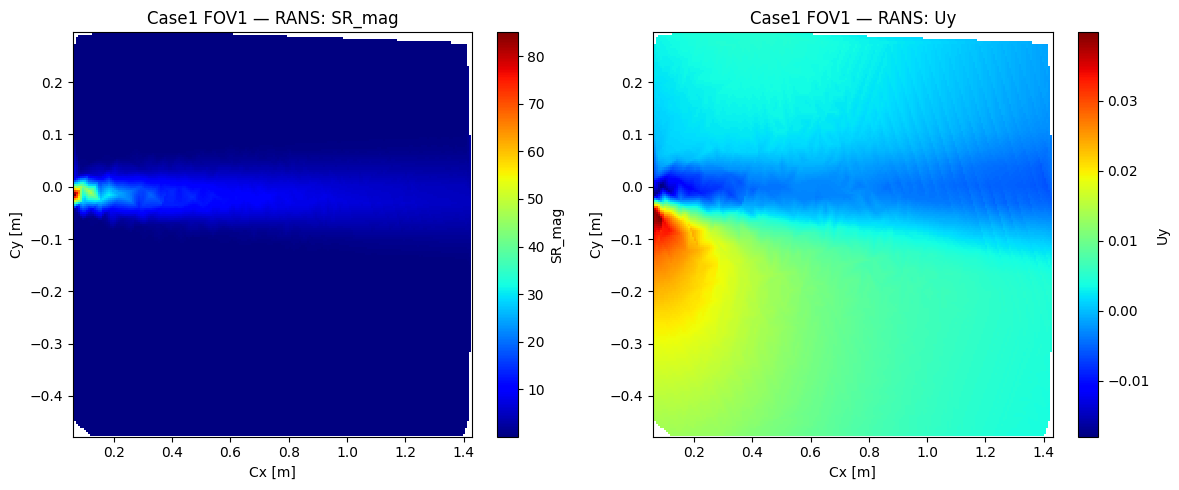

In [60]:
# Example: plot velocity magnitude
'''
 'Q_crit', 'Q_norm', 'rho_UxUx', 'rho_UxUy', 'rho_UxUz', 'rho_UyUy', 'rho_UyUz', 'rho_UzUz', 
 'Tao_xx', 'Tao_yy', 'Tao_zz', 'Tao_xy', 'Tao_yx', 'Tao_xz', 'Tao_zx', 'Tao_yz', 'Tao_zy',
 'Adv_x', 'Adv_y', 'Adv_z', 'strain_adv_x', 'strain_adv_y', 'strain_adv_z', 
 'rot_adv_x', 'rot_adv_y', 'rot_adv_z', 'Strain_adv_mag', 'Rot_adv_mag', 
 'S_vs_R', 'Str_pref_adv', 'Rot_pref_adv', 'cos_theta_adv',
 'tr_S2', 'tr_R2', 'tr_S3', 'tr_R2_S', 'tr_R2_S2', 'tr_SR', 'tr_SRS', 'tr_RSR', 'tr_S4', 'tr_R4', 'tr_S2R2',
'S_mag', 'R_mag', 'S2_mag', 'R2_mag', 'S3_mag', 'R2S_mag', 'R2S2_mag', 
'SR_mag', 'RS_mag', 'SRS_mag', 'RSR_mag', 'S4_mag', 'R4_mag', 'S2R2_mag', 'Adv_mag', 
'strain_adv_mag', 'rot_adv_mag', 'div_rho_uiuj_mag', 'comp_mag', 'div_Tao_mag'
'''
rans_feature = 'SR_mag'
rans_feature2 = ''
#rans_copy['U_mag'] = np.sqrt(rans_copy['Ux']**2 + rans_copy['Uy'])
plot_field_comparison(df1=rans_copy, df2=rans_df,var1=rans_feature, var2=rans_feature2,t1="RANS", t2="RANS", fov=fov, case=case, smooth=True, equal_colorbar=False)

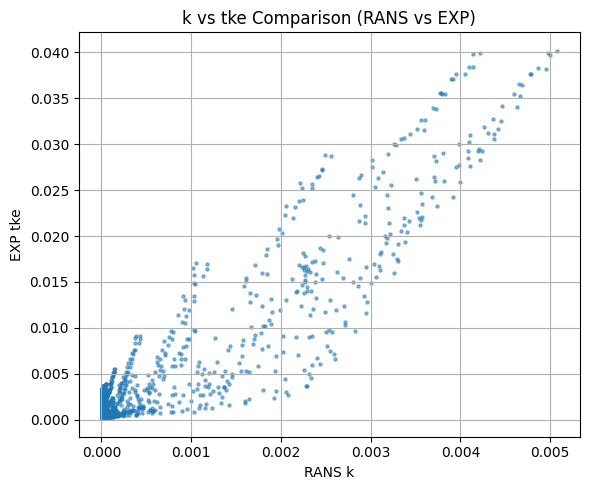

In [58]:
rans_feat = 'k'
exp_feat = 'tke'

plt.figure(figsize=(6,5))
plt.scatter(rans_df[rans_feat], exp_df[exp_feat], s=5, alpha=0.5)
plt.xlabel(f'RANS {rans_feat}')
plt.ylabel(f'EXP {exp_feat}')
plt.title(f'{rans_feat} vs {exp_feat} Comparison (RANS vs EXP)')
plt.grid(True)
plt.tight_layout()
plt.show()


# Tensor Basis Neural Network (TBNN) Overview

---

## Model Definition

The Tensor Basis Neural Network (TBNN) learns a mapping between invariant scalar quantities and tensorial outputs consistent with physical symmetries.

$$
\mathbf{b} = \sum_{n=1}^{N} g^{(n)}(\lambda_1, \ldots, \lambda_5) \, \mathbf{T}^{(n)}
$$

where:

- $\mathbf{b}$: predicted anisotropy tensor  
- $g^{(n)}$: scalar coefficient functions learned by the neural network  
- $\mathbf{T}^{(n)}$: fixed tensor basis functions (Pope, 1975)  
- $\lambda_i$: invariant scalar functions of strain-rate and rotation tensors  

---

## Input Tensors

Strain-rate and rotation-rate tensors are defined as:

$$
S = \frac{1}{2} \left( \nabla \mathbf{U} + (\nabla \mathbf{U})^T \right)
$$

$$
R = \frac{1}{2} \left( \nabla \mathbf{U} - (\nabla \mathbf{U})^T \right)
$$

where $\nabla \mathbf{U}$ is the velocity gradient tensor.

---

## Pope Tensor Basis (1975)

The ten basis tensors are:

$$
\begin{aligned}
\mathbf{T}^{(1)} &= S, \\
\mathbf{T}^{(2)} &= SR - RS, \\
\mathbf{T}^{(3)} &= S^2 - \frac{1}{3} \text{tr}(S^2)\,I, \\
\mathbf{T}^{(4)} &= R^2 - \frac{1}{3} \text{tr}(R^2)\,I, \\
\mathbf{T}^{(5)} &= R S^2 - S^2 R, \\
\mathbf{T}^{(6)} &= R^2 S + S R^2 - \frac{2}{3} \text{tr}(S R^2)\,I, \\
\mathbf{T}^{(7)} &= R S R^2 - R^2 S R, \\
\mathbf{T}^{(8)} &= S R S^2 - S^2 R S, \\
\mathbf{T}^{(9)} &= R^2 S^2 + S^2 R^2 - \frac{2}{3} \text{tr}(S^2 R^2)\,I, \\
\mathbf{T}^{(10)} &= R S^2 R^2 - R^2 S^2 R.
\end{aligned}
$$

Each $\mathbf{T}^{(n)}$ is **symmetric and traceless**, ensuring Galilean and rotational invariance.

---

## Pope Invariants

The five scalar invariants are functions of $S$ and $R$:

$$
\begin{aligned}
\lambda_1 &= \text{tr}(S^2), \\
\lambda_2 &= \text{tr}(R^2), \\
\lambda_3 &= \text{tr}(S^3), \\
\lambda_4 &= \text{tr}(R^2 S^2), \\
\lambda_5 &= \text{tr}(R^2 S^3).
\end{aligned}
$$

These are **inputs** to the neural network, ensuring that the learned mapping depends only on rotationally invariant quantities.

---

## Symmetrization

When the model predicts $\mathbf{b}$, numerical noise or incomplete basis representation may lead to asymmetry.
To enforce physical consistency:

$$
\mathbf{A}_{\text{sym}} = \frac{1}{2} \left( \mathbf{A} + \mathbf{A}^T \right)
$$

This **projects** $\mathbf{b}$ onto the **symmetric subspace** of tensors, ensuring that only the physically meaningful (symmetric) part contributes — antisymmetric parts are removed.

Intuitively:
- $\mathbf{b}_{\text{sym}}$ keeps only the “mirrored” information across the diagonal.
- It’s equivalent to orthogonally projecting onto the space of symmetric tensors.

---

# Recommended Visualizations

To supplement prediction plots, include these feature diagnostics:

### 1. Invariant Distributions
- Kernel density or scatter plots of $(\lambda_1, \lambda_2, \lambda_3, \lambda_4, \lambda_5)$
- Color by case or training/testing split
- Highlights the range of scalar features seen by the network

### 2. Tensor Basis Magnitudes
- Plot $\| \mathbf{T}^{(n)} \|_F$ (Frobenius norm) vs. spatial coordinate
- Useful to show relative strength or spatial structure of each basis

### 3. Scalar Coefficient Outputs
- After training: plot $g^{(n)}(\lambda)$ as a function of invariants
- Compare distributions between training and testing domains

### 4. Symmetry Check
- Heatmap of $\mathbf{b} - \mathbf{b}^T$ before and after symmetrization
- Demonstrates projection effect and model physical consistency

### 5. Tensor Field Comparisons
- Standard prediction plots: true vs. predicted vs. difference for each anisotropy component
- Optionally overlay Frobenius norm of error field

---


### Pope Tensor Basis (1975) — Physical Meaning

- **T¹ = S:** Linear strain-rate contribution (primary deformation mode).  
- **T² = SR − RS:** Coupling between strain and rotation — captures swirling shear effects.  
- **T³ = S² − (1/3)tr(S²)I:** Quadratic strain effects; traceless to remove isotropic part.  
- **T⁴ = R² − (1/3)tr(R²)I:** Quadratic rotation effects; represents pure rotational influence.  
- **T⁵ = RS² − S²R:** Nonlinear strain–rotation coupling; rotation acting on strain squares.  
- **T⁶ = R²S + SR² − (2/3)tr(SR²)I:** Rotation–strain–rotation triple interaction.  
- **T⁷ = RSR² − R²SR:** Higher-order rotation–strain coupling.  
- **T⁸ = SRS² − S²RS:** Higher-order strain–rotation coupling.  
- **T⁹ = R²S² + S²R² − (2/3)tr(S²R²)I:** Combined fourth-order strain–rotation product, symmetric part.  
- **T¹⁰ = RS²R² − R²S²R:** Fifth-order coupling, most complex interaction term.

All $\mathbf{T}^{(n)}$ are **symmetric**, **traceless**, and **rotationally invariant**, ensuring Galilean consistency.

---

### Pope Invariants (λ₁–λ₅) — Physical Meaning

1. **λ₁ = tr(S²):** Magnitude of strain-rate (rate of deformation intensity).  
2. **λ₂ = tr(R²):** Magnitude of rotation-rate (vorticity intensity).  
3. **λ₃ = tr(S³):** Skewness of the strain field (nonlinear deformation).  
4. **λ₄ = tr(R²S²):** Coupling between strain and rotation energy.  
5. **λ₅ = tr(R²S³):** Higher-order strain–rotation coupling measure.


In [50]:
import torch
import pandas as pd

def compute_pope_features_from_df(df, device='cpu'):
    """
    Wrapper: extract S and R tensors from a DataFrame with column names like 'S_xy', 'R_yz', etc.
    Computes Pope (1975) invariants λ₁–λ₅ and tensor basis Frobenius norms.

    Expected columns:
        ['S_xx','S_xy','S_xz','S_yx','S_yy','S_yz','S_zx','S_zy','S_zz']
        ['R_xx','R_xy','R_xz','R_yx','R_yy','R_yz','R_zx','R_zy','R_zz']

    Returns:
        invariants (dict[str, Tensor])
        basis_norms (list[Tensor])  # ||Tⁿ||_F for n=1..10
    """

    # --- Define column order ---
    s_keys = ['S_xx','S_xy','S_xz','S_yx','S_yy','S_yz','S_zx','S_zy','S_zz']
    r_keys = ['R_xx','R_xy','R_xz','R_yx','R_yy','R_yz','R_zx','R_zy','R_zz']

    # --- Check columns ---
    if not all(k in df.columns for k in s_keys + r_keys):
        missing = [k for k in s_keys + r_keys if k not in df.columns]
        raise ValueError(f"Missing expected tensor columns: {missing}")

    # --- Convert to tensors ---
    S = torch.tensor(df[s_keys].values, dtype=torch.float32, device=device).view(-1, 3, 3)
    R = torch.tensor(df[r_keys].values, dtype=torch.float32, device=device).view(-1, 3, 3)

    # --- Precompute ---
    S2 = torch.bmm(S, S)
    R2 = torch.bmm(R, R)
    I = torch.eye(3, device=device).unsqueeze(0).repeat(S.shape[0], 1, 1)
    trace = lambda A: torch.einsum('nii->n', A)

    # --- Invariants ---
    invariants = {
        'λ1': trace(S2),
        'λ2': trace(R2),
        'λ3': trace(torch.bmm(S, S2)),
        'λ4': trace(torch.bmm(R2, S2)),
        'λ5': trace(torch.bmm(R2, torch.bmm(S, S2)))
    }

    # --- Tensor basis ---
    T = []
    T.append(S)  # T1
    T.append(torch.bmm(S, R) - torch.bmm(R, S))  # T2
    T.append(S2 - (1/3)*trace(S2).view(-1,1,1)*I)  # T3
    T.append(R2 - (1/3)*trace(R2).view(-1,1,1)*I)  # T4
    T.append(torch.bmm(R, S2) - torch.bmm(S2, R))  # T5
    T.append(torch.bmm(R2, S) + torch.bmm(S, R2) - (2/3)*trace(torch.bmm(S, R2)).view(-1,1,1)*I)  # T6
    T.append(torch.bmm(torch.bmm(R, S), R2) - torch.bmm(torch.bmm(R2, S), R))  # T7
    T.append(torch.bmm(torch.bmm(S, R), S2) - torch.bmm(torch.bmm(S2, R), S))  # T8
    T.append(torch.bmm(R2, S2) + torch.bmm(S2, R2) - (2/3)*trace(torch.bmm(S2, R2)).view(-1,1,1)*I)  # T9
    T.append(torch.bmm(torch.bmm(R, S2), R2) - torch.bmm(torch.bmm(R2, S2), R))  # T10

    frob_norm = lambda A: torch.sqrt(torch.sum(A**2, dim=(1,2)))
    basis_norms = [frob_norm(t) for t in T]

    return invariants, basis_norms


/var/folders/zc/f4jkfc0x3x1027959gy5sc_c0000gn/T/ipykernel_28006/1285026344.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rans_df[k] = v.cpu().numpy()
/var/folders/zc/f4jkfc0x3x1027959gy5sc_c0000gn/T/ipykernel_28006/1285026344.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rans_df2[k] = inv_case2[k].cpu().numpy()
/var/folders/zc/f4jkfc0x3x1027959gy5sc_c0000gn/T/ipykernel_28006/1285026344.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

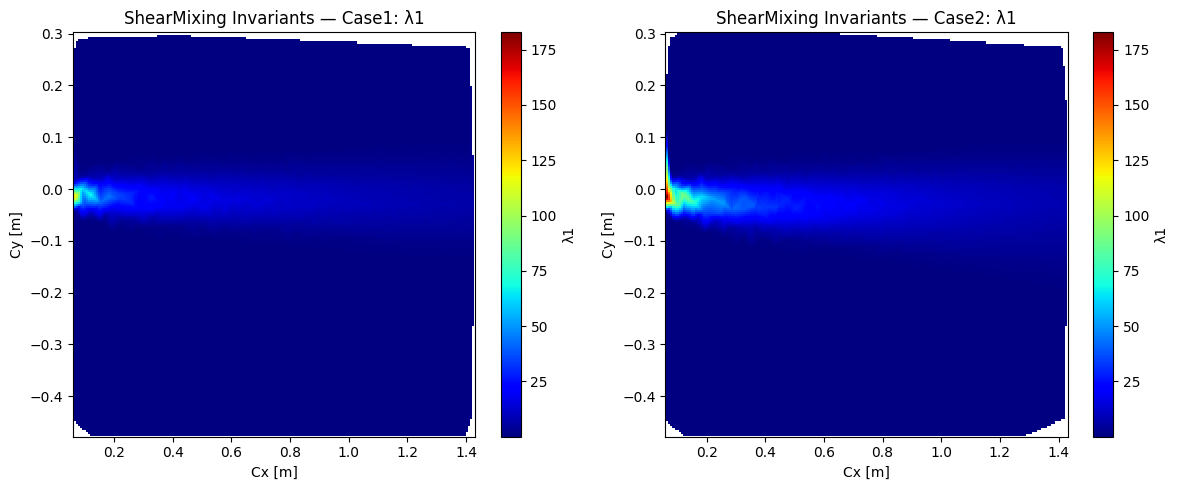

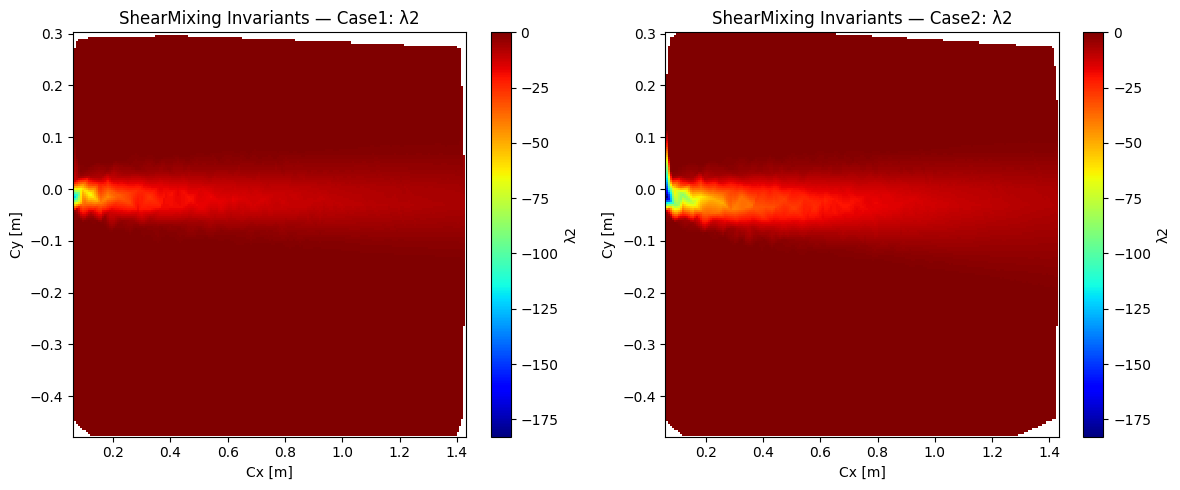

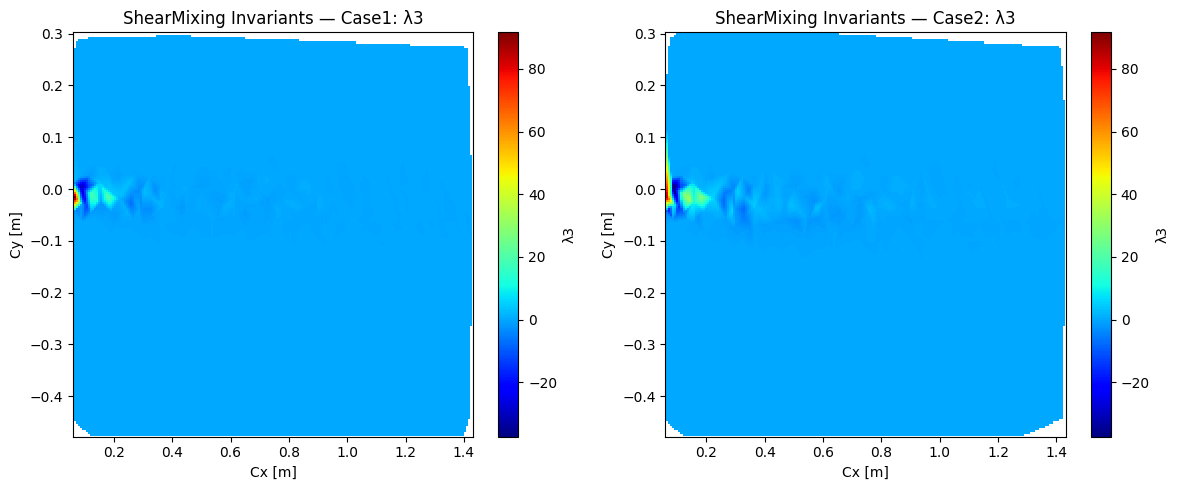

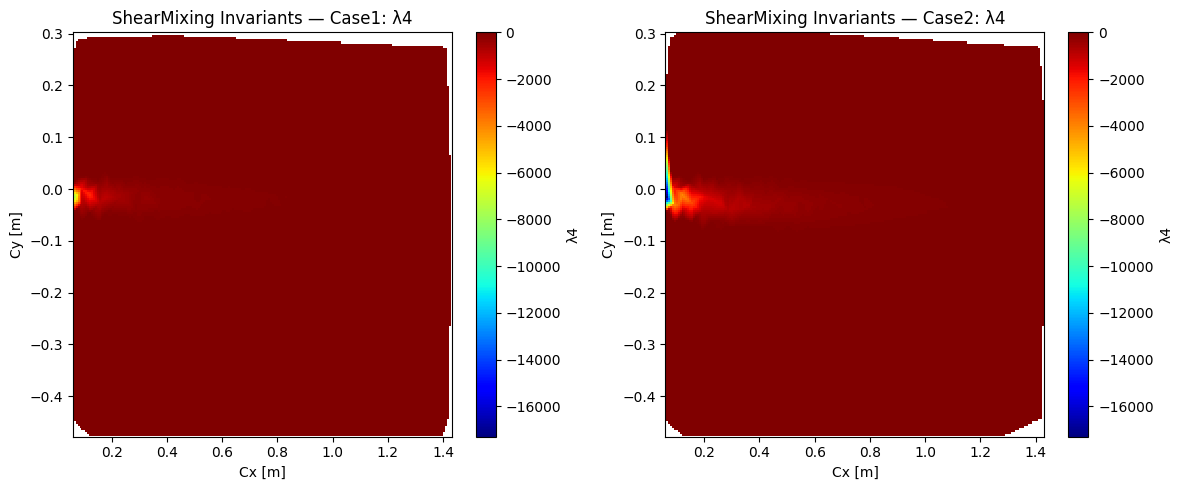

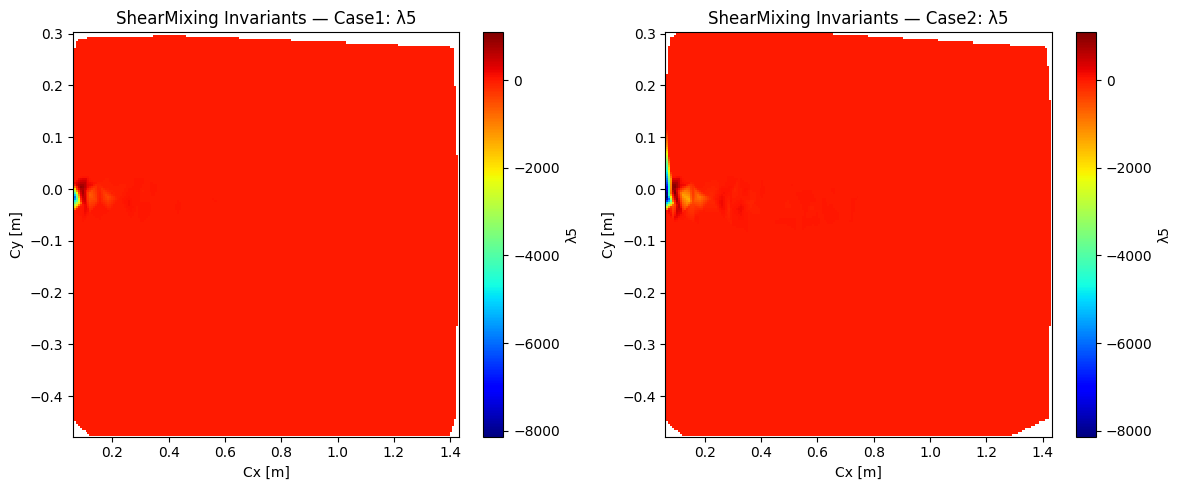

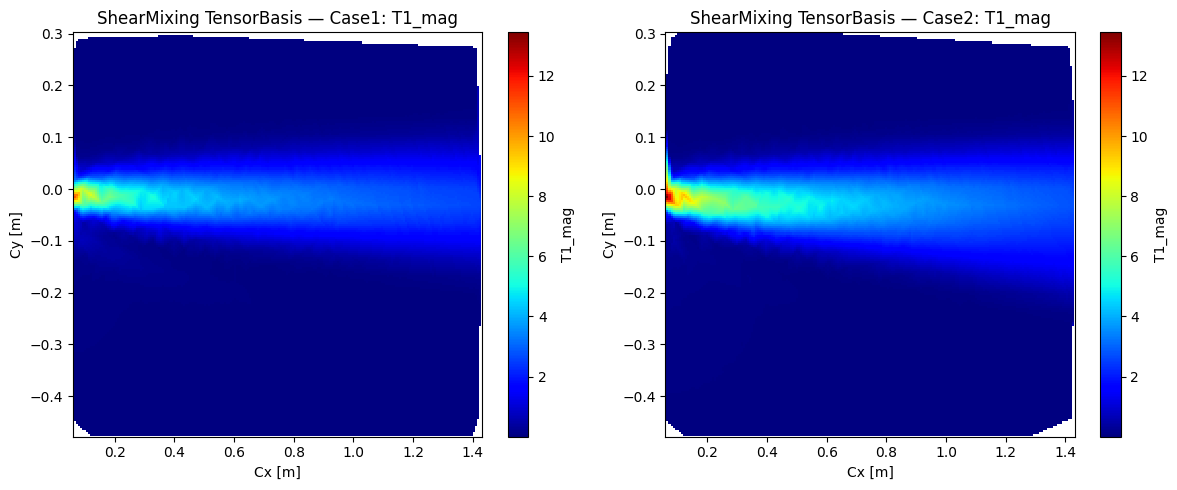

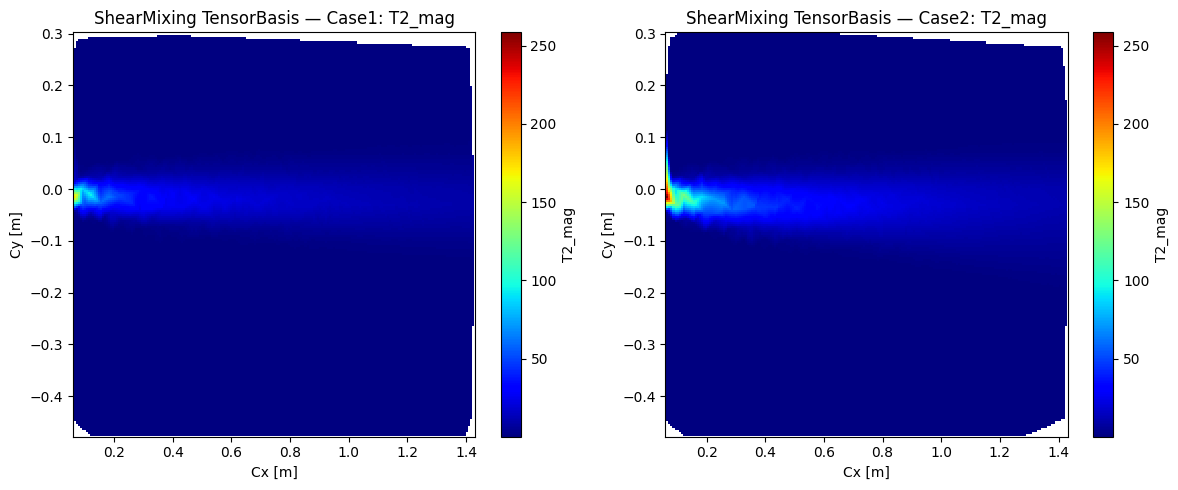

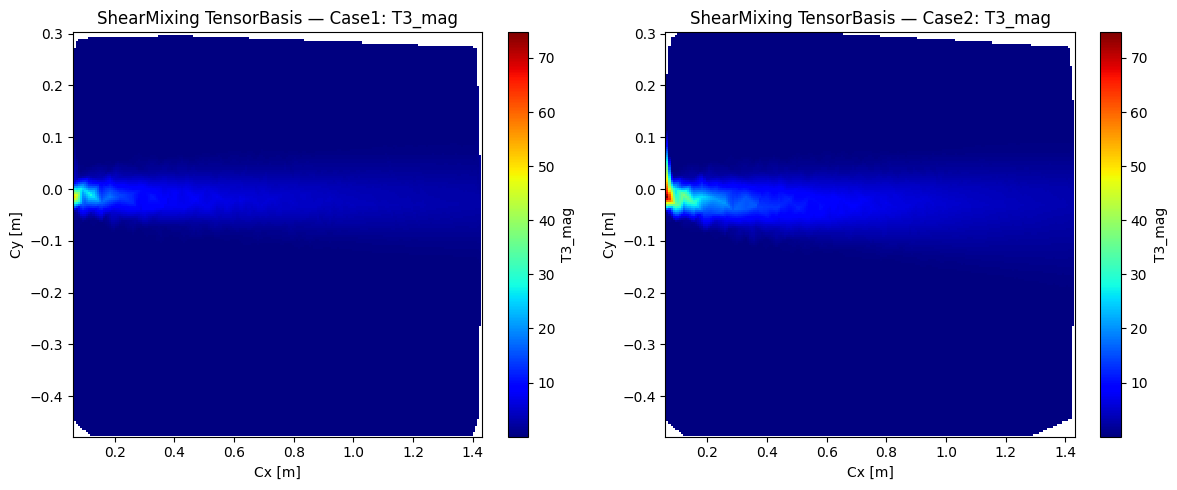

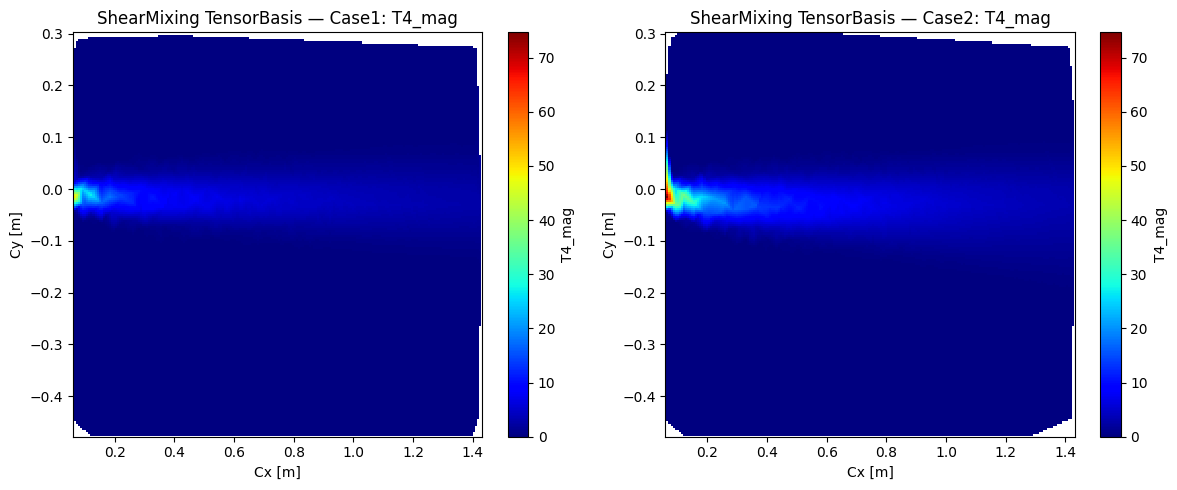

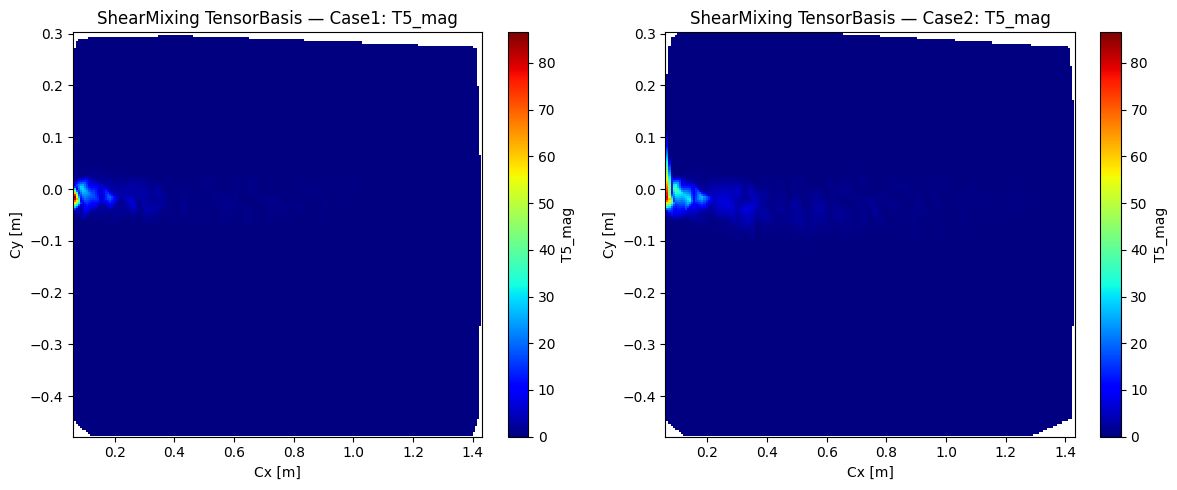

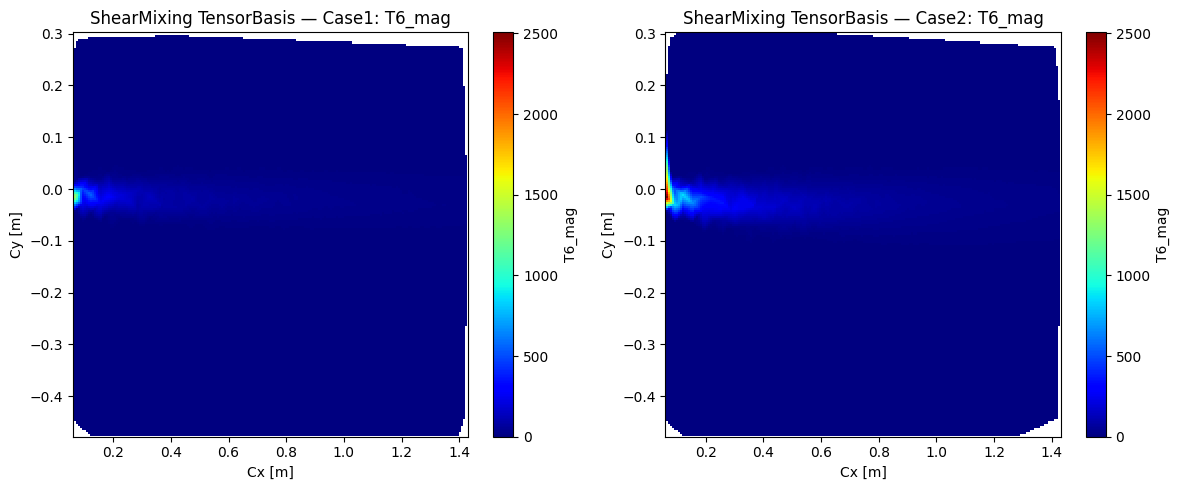

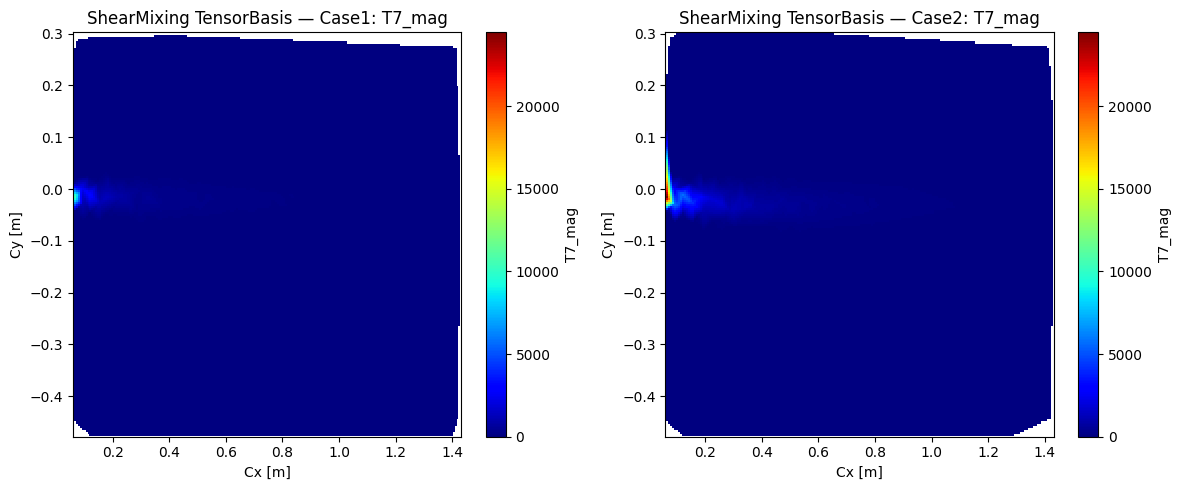

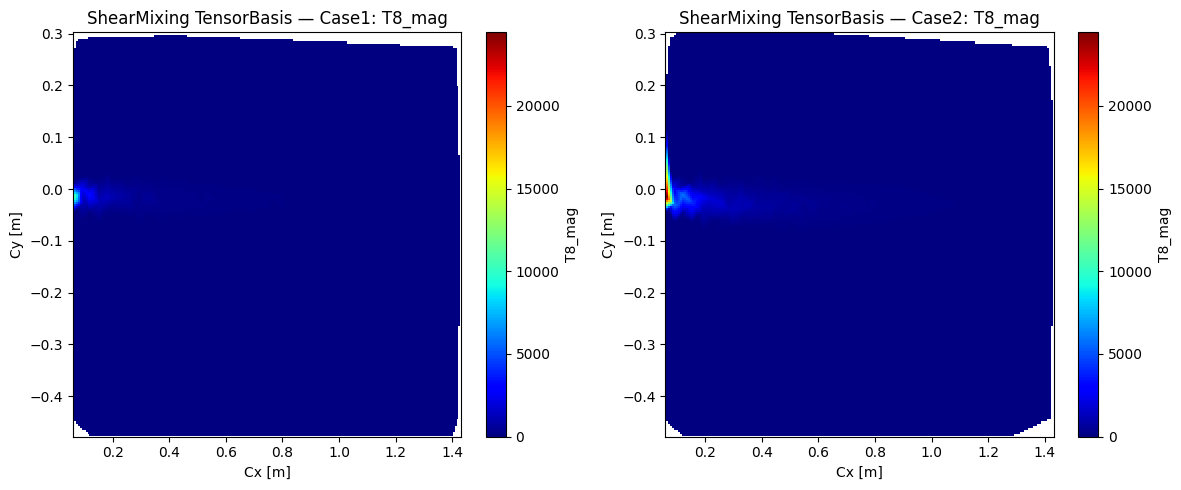

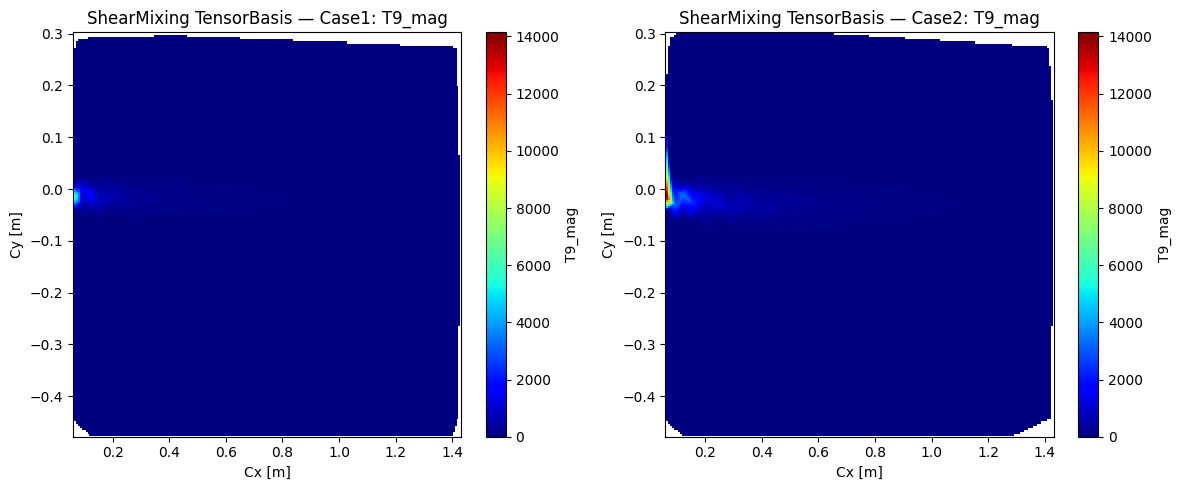

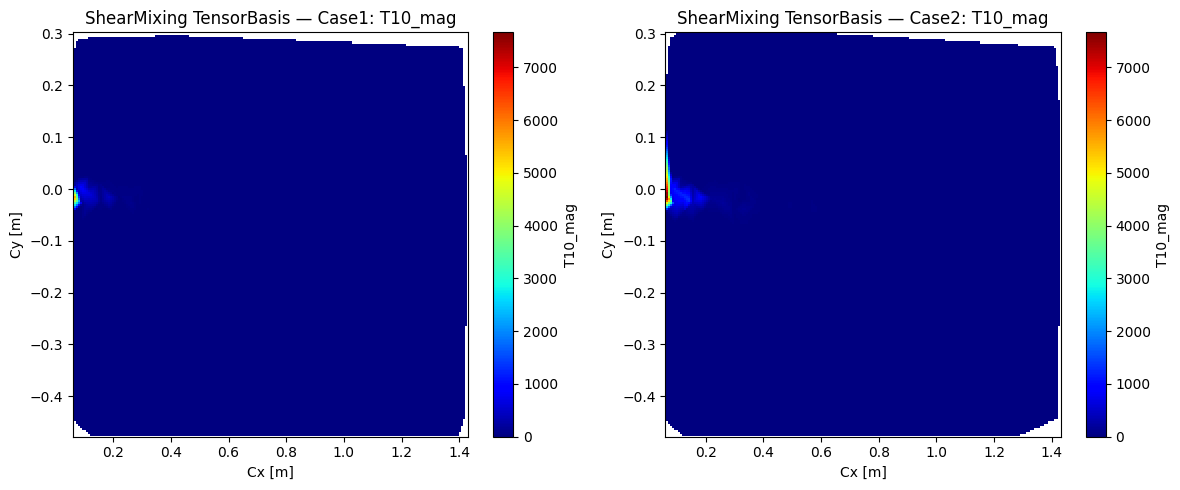

In [59]:
# --- Compute features ---
invariants, basis_norms = compute_pope_features_from_df(rans_df)
inv_case2, basis_case2 = compute_pope_features_from_df(rans_df2)

# --- Add to DataFrames for plotting ---
for i, (k, v) in enumerate(invariants.items()):
    rans_df[k] = v.cpu().numpy()
    rans_df2[k] = inv_case2[k].cpu().numpy()

for i, b in enumerate(basis_norms):
    rans_df[f'T{i+1}_mag'] = b.cpu().numpy()
    rans_df2[f'T{i+1}_mag'] = basis_case2[i].cpu().numpy()

# --- Plot Pope invariants spatial comparison ---
for k in invariants.keys():
    plot_field_comparison(
        df1=rans_df,
        df2=rans_df2,
        var1=k,
        var2=k,
        t1='Case1',
        t2='Case2',
        case='ShearMixing',
        fov='Invariants',
        cmap='jet',
        smooth=True
    )

# --- Plot tensor basis magnitudes spatial comparison ---
for i in range(10):
    plot_field_comparison(
        df1=rans_df,
        df2=rans_df2,
        var1=f'T{i+1}_mag',
        var2=f'T{i+1}_mag',
        t1='Case1',
        t2='Case2',
        case='ShearMixing',
        fov='TensorBasis',
        cmap='jet',
        smooth=True
    )
